# 15. LSTM — one model (Method #1)
The LSTM version of the class steps `DT_Regressor1 = DecisionTreeRegressor(...)` (building), `.fit(x_train, y_train)` (training) and `.predict(x_test)` (testing). We train **one** LSTM: trained on 2003–2006, tested on 2007, random seed 1. It takes about a minute.

* **Needs:** `work/model_data.csv`. **Makes:** `work/lstm_2007_seed1.pt` (the trained model) and two small files with its scaling numbers (used for SHAP in notebook 21).

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

## Data Preparation (the steps of notebook 14)

In [2]:
from pandas import read_csv
dataset = read_csv(folder + 'work/model_data.csv', index_col=0, parse_dates=True)
x = dataset[['ret', 'log_r2', 'us_ret', 'log_us_r2', 'euro_ret', 'log_euro_r2']]
y = dataset['log_rv5_fwd']
print(x.shape)
print(y.shape)

(5243, 6)
(5243,)


In [3]:
fit_days = y.iloc[21:].loc[:'2005-12-31'].dropna().index
fit_days = fit_days[:-5]
val_days = y.loc['2006-01-01':'2006-12-31'].dropna().index
val_days = val_days[:-5]
test_days = y.loc['2007-01-01':'2007-12-31'].dropna().index
print('fitting   :', len(fit_days), 'days,', fit_days[0].date(), 'to', fit_days[-1].date())
print('validation:', len(val_days), 'days,', val_days[0].date(), 'to', val_days[-1].date())
print('test      :', len(test_days), 'days,', test_days[0].date(), 'to', test_days[-1].date())

fitting   : 734 days, 2003-01-31 to 2005-12-21
validation: 248 days, 2006-01-03 to 2006-12-20
test      : 254 days, 2007-01-02 to 2007-12-31


In [4]:
mean = x.loc[:fit_days[-1]].mean()
std = x.loc[:fit_days[-1]].std()
x_scaled = (x - mean) / std

y_mean = y.loc[fit_days].mean()
y_std = y.loc[fit_days].std()
y_scaled = (y - y_mean) / y_std

In [5]:
from numpy import array
x_fit = []
for day in fit_days:
    position = x.index.get_loc(day)
    x_fit.append(x_scaled.values[position - 21:position + 1])
x_val = []
for day in val_days:
    position = x.index.get_loc(day)
    x_val.append(x_scaled.values[position - 21:position + 1])
x_test = []
for day in test_days:
    position = x.index.get_loc(day)
    x_test.append(x_scaled.values[position - 21:position + 1])

import torch
x_fit = torch.tensor(array(x_fit, dtype='float32'))
y_fit = torch.tensor(array(y_scaled.loc[fit_days], dtype='float32'))
x_val = torch.tensor(array(x_val, dtype='float32'))
y_val = torch.tensor(array(y_scaled.loc[val_days], dtype='float32'))
x_test = torch.tensor(array(x_test, dtype='float32'))
print(x_fit.shape, x_val.shape, x_test.shape)

torch.Size([734, 22, 6]) torch.Size([248, 22, 6]) torch.Size([254, 22, 6])


## How an LSTM works, in short
A **Long Short-Term Memory** network reads the 22 days **one after the other** and keeps a **memory**. At every day, three learned 'gates' decide what to **forget**, what new information to **store**, and what to **pass on**. After the 22nd day, a final layer turns the memory into one number: the forecast.

In class, `DecisionTreeRegressor()` came ready-made from scikit-learn. A neural network is described with a small **class** — a blueprint with two parts: `__init__` lists the layers, `forward` says how the data flows through them.

| Layer | What it does |
|---|---|
| `nn.LSTM(6, 64, num_layers=2, …)` | two stacked LSTM layers; 6 inputs per day, a memory of 64 numbers |
| `nn.Dropout(0.2)` | during training, switches off 20% of the memory at random, so the model cannot just memorise (prevents over-fitting) |
| `nn.Linear(64, 1)` | turns the 64 memory numbers into one forecast |

In [6]:
from torch import nn
torch.set_num_threads(2)


class LSTMVol(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)   # 6 inputs, 64 units, 2 layers
        self.drop = nn.Dropout(0.2)
        self.head = nn.Linear(64, 1)                                                # one number out

    def forward(self, x):
        out, _ = self.lstm(x)                  # read the 22 days, one after the other
        last_day = out[:, -1]                  # the memory after the last day
        return self.head(self.drop(last_day)).squeeze(-1)

# LSTM
## Modelling
The random **seed** fixes the random starting values, so the result can be repeated exactly (like `random_state=100` in class).

In [7]:
torch.manual_seed(1)
from numpy import random
random.seed(1)
LSTM_Regressor1 = LSTMVol()         # building
print(LSTM_Regressor1)

LSTMVol(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (drop): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


### Training
* **Loss:** mean squared error on the scaled log volatility. **Optimiser:** `Adam` with learning rate 0.001 — the method that adjusts the weights a little after each batch.
* **Epoch** = one pass through all fitting windows, in **batches of 64** (shuffled each epoch).
* After every epoch we compute the loss on the **validation** days. If it has not improved for **15 epochs**, we stop (**early stopping**) and keep the best weights — this prevents over-fitting.

In [8]:
optimizer = torch.optim.Adam(LSTM_Regressor1.parameters(), lr=0.001)
loss_function = nn.MSELoss()

In [9]:
best_val_loss = 1000000.0
wait = 0
for epoch in range(1, 201):
    LSTM_Regressor1.train()                              # training mode (dropout on)
    order = torch.randperm(len(x_fit))                   # shuffle the fitting windows
    for start in range(0, len(x_fit), 64):               # batches of 64
        batch = order[start:start + 64]
        optimizer.zero_grad()
        loss = loss_function(LSTM_Regressor1(x_fit[batch]), y_fit[batch])
        loss.backward()                                  # how should each weight change?
        optimizer.step()                                 # change the weights a little

    LSTM_Regressor1.eval()                               # evaluation mode (dropout off)
    with torch.no_grad():
        val_loss = loss_function(LSTM_Regressor1(x_val), y_val).item()
    print('epoch', epoch, '| validation loss', round(val_loss, 4))

    if val_loss < best_val_loss - 0.0001:                # better than before: remember these weights
        best_val_loss = val_loss
        best_weights = {}
        for name, value in LSTM_Regressor1.state_dict().items():
            best_weights[name] = value.clone()
        wait = 0
    else:
        wait = wait + 1
        if wait >= 15:
            print('no improvement for 15 epochs: stop')
            break

LSTM_Regressor1.load_state_dict(best_weights)           # keep the best weights
LSTM_Regressor1.eval()
print('best validation loss =', round(best_val_loss, 4))

epoch 1 | validation loss 1.1268


epoch 2 | validation loss 0.9934


epoch 3 | validation loss 1.0007


epoch 4 | validation loss 0.9637


epoch 5 | validation loss 0.9384
epoch 6 | validation loss 0.9545


...

epoch 19 | validation loss 0.9541


epoch 20 | validation loss 0.9934
epoch 21 | validation loss 0.996


epoch 22 | validation loss 1.0345


epoch 23 | validation loss 1.0632


epoch 24 | validation loss 1.0786
no improvement for 15 epochs: stop
best validation loss = 0.9288


### The smearing factor
As for HAR (notebook 09), the forecast comes out in logs and $\exp$ of a log forecast is a little too small on average. The correction is measured on the **validation** days.

In [10]:
from numpy import exp
with torch.no_grad():
    val_pred_scaled = LSTM_Regressor1(x_val).numpy()
val_pred_log = val_pred_scaled * y_std + y_mean
smear = exp(y.loc[val_days].values - val_pred_log).mean()
print('smearing factor =', round(smear, 3))

smearing factor = 1.675


### Testing
The test windows go through the trained model; then we undo the scaling (× std + mean), undo the log (`exp`) and apply the smearing factor.

In [11]:
from pandas import Series
with torch.no_grad():
    test_pred_scaled = LSTM_Regressor1(x_test).numpy()
y_pred1 = Series(exp(test_pred_scaled * y_std + y_mean) * smear, index=test_days)    # testing
y_pred1.head()

2007-01-02    0.000244
2007-01-03    0.000249
2007-01-04    0.000257
2007-01-05    0.000265
2007-01-08    0.000284
dtype: float64

## Evaluation

In [12]:
from numpy import log
y_test = dataset.loc[test_days, 'rv5_fwd']
ratio = y_test / y_pred1
QLIKE1 = (ratio - log(ratio) - 1).mean()
print('QLIKE (LSTM, one model, 2007) =', round(QLIKE1, 3))

QLIKE (LSTM, one model, 2007) = 0.813


One LSTM is worse than GARCH (0.52) and HAR (0.66) in 2007. The study averages **5** models (seeds) per year — notebook 17. Check against the saved forecasts of seed 1:

In [13]:
saved = read_csv(folder + 'results/lstm_forecasts.csv', index_col=0, parse_dates=True)
print('largest relative difference:', ((y_pred1 / saved.loc[test_days, 'LSTM_seed1']) - 1).abs().max())

largest relative difference: 4.070077608275824e-13


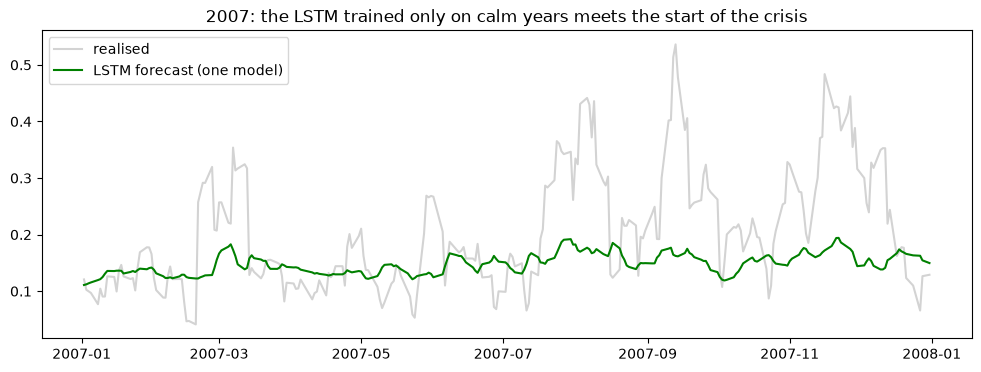

In [14]:
from numpy import sqrt
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(sqrt(y_test * 252 / 5), color='lightgrey', label='realised')
plt.plot(sqrt(y_pred1 * 252 / 5), color='green', label='LSTM forecast (one model)')
plt.legend()
plt.title('2007: the LSTM trained only on calm years meets the start of the crisis')
plt.show()

## Save the model
Like `joblib.dump(best_svc, 'MysvcModel.pkl')` in class. For PyTorch we save the weights with `torch.save`, and the scaling numbers in two small CSV files.

In [15]:
from pandas import DataFrame
torch.save(LSTM_Regressor1.state_dict(), folder + 'work/lstm_2007_seed1.pt')
DataFrame({'mean': mean, 'std': std}).to_csv(folder + 'work/lstm_2007_seed1_scaling.csv')
DataFrame({'value': [y_mean, y_std, smear]}, index=['y_mean', 'y_std', 'smear']).to_csv(folder + 'work/lstm_2007_seed1_target.csv')
print('saved')

saved
